In [18]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.datasets import mnist

In [19]:
(x_train, t_train), (x_test, t_test) = mnist.load_data()

In [20]:
print('\n train shape = ', x_train.shape)
print('\n, train label shape = ', t_train.shape)
print('\n test shape = ', x_test.shape)
print('\n, test label shape = ', t_test.shape)

print('\n train label = ', t_train)
print('\n test label = ', t_test)


 train shape =  (60000, 28, 28)

, train label shape =  (60000,)

 test shape =  (10000, 28, 28)

, test label shape =  (10000,)

 train label =  [5 0 4 ... 5 6 8]

 test label =  [7 2 1 ... 4 5 6]


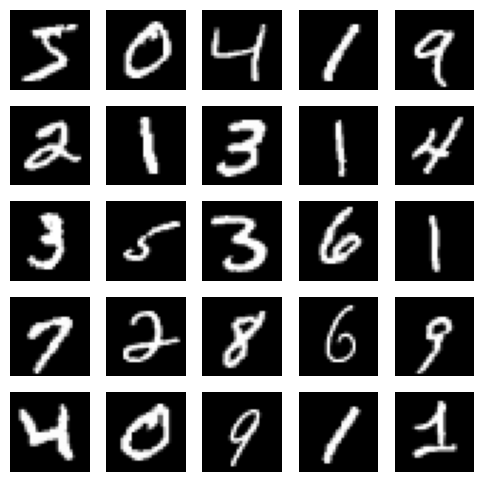

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
for index in range(25):
    plt.subplot(5,5, index + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.axis('off')

plt.show()

In [22]:
x_train = (x_train - 0.0 / (255.0 - 0.0))
# print(x_train)
x_test = (x_test - 0.0 / (255.0 - 0.0))

In [23]:
t_train = tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test = tf.keras.utils.to_categorical(t_test, num_classes=10)

In [25]:
model =Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(100, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy']
              )
model.summary()

/home/work/git/TensorflowPjt/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1781586646.679398  206080 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

노두수 2/3(입력수 + 출력수)

In [26]:
hist = model.fit(x_train, t_train, epochs=30, validation_split=0.3)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8175 - loss: 3.0510 - val_accuracy: 0.8751 - val_loss: 0.6370
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8925 - loss: 0.4723 - val_accuracy: 0.9046 - val_loss: 0.5245
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9147 - loss: 0.3474 - val_accuracy: 0.9089 - val_loss: 0.3653
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9297 - loss: 0.2717 - val_accuracy: 0.9222 - val_loss: 0.3413
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9370 - loss: 0.2480 - val_accuracy: 0.9317 - val_loss: 0.3324
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9397 - loss: 0.2404 - val_accuracy: 0.9334 - val_loss: 0.3176
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9433 - loss: 0.2218 - val_accuracy: 0.9394 - val_loss: 0.2822
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9479 - loss: 0.2046 - 

In [27]:
model.evaluate(x_test,t_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9475 - loss: 0.4427


[0.44274359941482544, 0.9474999904632568]

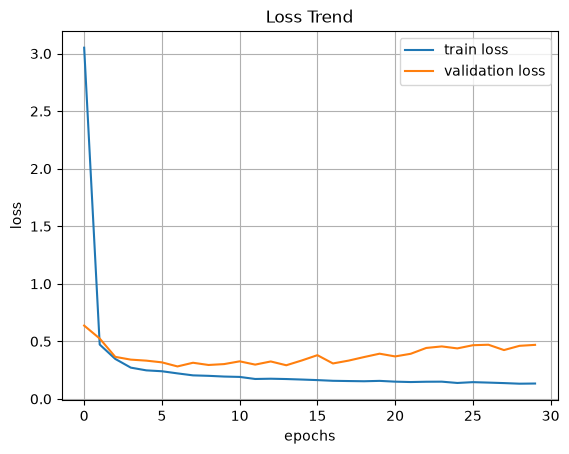

In [28]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')
plt.legend(loc='best')
plt.show()

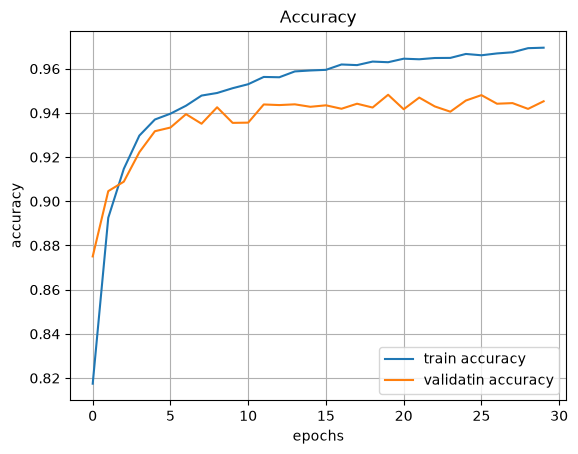

In [29]:
import matplotlib.pyplot as plt

plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()
plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validatin accuracy')
plt.legend(loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Axes: >

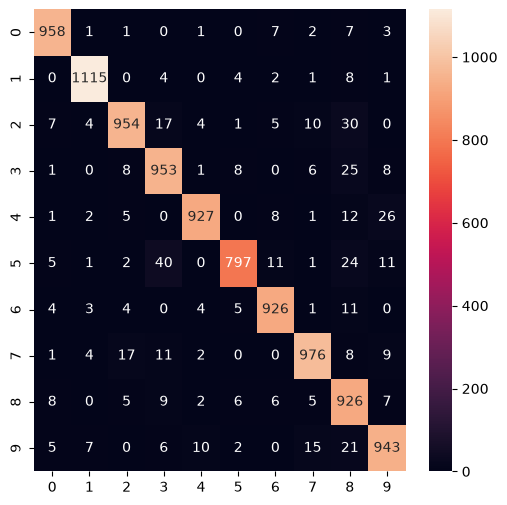

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
plt.figure(figsize=(6,6))
predicted_value = model.predict(x_test)

cm = confusion_matrix(np.argmax(t_test, axis=-1),
                      np.argmax(predicted_value, axis=-1))
sns.heatmap(cm, annot=True, fmt='d')